# I - Imports

In [1]:
import numpy as np
import os
import pandas as pd
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from itertools import product
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up the root directory
root_dir = r"C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition"

os.chdir(root_dir)

os.getcwd()

'C:\\Users\\Source\\OneDrive - IESEG\\Desktop\\MBD\\ML\\Kaggle_Competition'

# II - Loading

In [3]:
train = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'train_preprocessed.csv'), index_col="ID")
train_labels = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'y_train.csv'))
test = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'test_preprocessed.csv'), index_col="ID")

In [4]:
# Verifying the imports
display(train.head(3))
display(train_labels.head(3))
display(test.head(3))

,Var5,Var7,Var11,Var13,Var17,Var19,Var20,Var21,Var22,Var28,...,Var14822_freq,Var14893_freq,Var14904_freq,Var14910_freq,Var14913_freq,Var14923_freq,Var14965_freq,Var14970_freq,Var14990_freq,Var14993_freq
ID,,,,,,,,,,,,,,,,,,,,,
502504,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84608.0,1702392.0,...,0.000167,0.000833,0.000033,0.959833,0.000233,0.5867,0.071467,0.079633,0.082333,0.000833
197332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1481512.0,846372.0,...,0.000067,0.001433,0.007033,0.959833,0.000600,0.5867,0.005167,0.347167,0.082333,0.001433
277830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9176480.0,478698.0,...,0.000033,0.000167,0.002667,0.959833,0.000100,0.5867,0.002233,0.347167,0.028400,0.000167


,ID,Target_appetency
0,502504,0
1,197332,0
2,277830,0


,Var5,Var7,Var11,Var13,Var17,Var19,Var20,Var21,Var22,Var28,...,Var14822_freq,Var14893_freq,Var14904_freq,Var14910_freq,Var14913_freq,Var14923_freq,Var14965_freq,Var14970_freq,Var14990_freq,Var14993_freq
ID,,,,,,,,,,,,,,,,,,,,,
877149,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,495392.0,2592144.0,...,0.000667,0.000600,0.001300,0.959833,0.000700,0.128267,0.089000,0.057333,0.162700,0.000600
109603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23850.0,...,0.001333,0.001767,0.001100,0.959833,0.001367,0.128267,0.009433,0.023033,0.022400,0.001767
560424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14804640.0,1104144.0,...,0.000000,0.000400,0.011567,0.959833,0.000100,0.128267,0.006467,0.014467,0.027333,0.000400


# III - Modeling

## A) Setup

In [5]:
X_train = train.copy()
y_train_arr = train_labels['Target_appetency'].values

# Class imbalance ratio
neg = (y_train_arr == 0).sum()
pos = (y_train_arr == 1).sum()
scale_pos = neg / pos

# our k fold cv 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)


Computes out-of-fold predictions, then prints classification report and plots confusion matrix. threshold=0.5 is the default probability cutoff.


In [6]:
def evaluate_cv_classifier(model_name, estimator, X, y, cv, threshold=0.5):
    y_proba = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1)[:, 1]

    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n{model_name}  Classification Report")
    print(classification_report(y, y_pred, digits=4))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No appetency", "Appetency"])
    
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix, threshold={threshold}")
    plt.show()

    return y_proba, y_pred

## E) XGB

In [7]:
# XGBOOST with early stopping

# We do NOT put n_estimators in the grid — early stopping handles it.
# scale_pos_weight compensates for 1.8% minority class by telling
# XGBoost to penalise false negatives more heavily.
# eval_metric='auc' ensures early stopping monitors the right metric.

xgb_params = {
    'learning_rate': [0.05],
    'max_depth': [3, 5],
    'subsample':  [0.8],
    'colsample_bytree': [0.3, 0.4],
    'reg_alpha':  [0], # L1
    'reg_lambda':  [1, 5],  # L2
}

best_xgb_auc  = 0
best_xgb_params = {}
best_xgb_model  = None

# Manual CV loop to support early stopping inside each fold
param_combinations = [
    dict(zip(xgb_params.keys(), v))
    for v in product(*xgb_params.values())
]

print(f"XGBoost: {len(param_combinations)} combinations 5 folds")

for params in param_combinations:
    fold_aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = xgb.XGBClassifier(
            **params,
            n_estimators=2000,          # large upper bound
            scale_pos_weight=scale_pos,
            eval_metric='auc',
            early_stopping_rounds=50,   # stops if no improvement for 50 rounds
            random_state=123,
            n_jobs=-1,
            verbosity=2
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_xgb_auc:
        best_xgb_auc    = mean_auc
        best_xgb_params = params
        best_xgb_model  = model   # last fold's model — refit below

XGBoost: 8 combinations 5 folds
[20:09:16] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (24000, 5123, 122952000).
[20:09:18] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (6000, 5123, 30738000).
[20:09:56] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (24000, 5123, 122952000).
[20:09:57] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (6000, 5123, 30738000).
[20:10:39] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (24000, 5123, 122952000).
[20:10:41] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (6000, 5123, 3073800

In [8]:
print(f"Best AUC (CV): {best_xgb_auc:.4f}")
print(f"Best params: {best_xgb_params}")

Best AUC (CV): 0.8521
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.3, 'reg_alpha': 0, 'reg_lambda': 5}


In [9]:
# Refit best params on full training set
final_xgb = xgb.XGBClassifier(
    **best_xgb_params,
    n_estimators=400,
    scale_pos_weight=scale_pos,
    random_state=123,
    n_jobs=-1,
    verbosity=2
)
final_xgb.fit(X_train, y_train_arr)
xgb_pred = final_xgb.predict_proba(test)[:, 1]

[20:40:26] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (30000, 5123, 153690000).



XGBoost  Classification Report
              precision    recall  f1-score   support

           0     0.9893    0.9279    0.9576     29466
           1     0.1003    0.4438    0.1637       534

    accuracy                         0.9193     30000
   macro avg     0.5448    0.6859    0.5606     30000
weighted avg     0.9734    0.9193    0.9435     30000



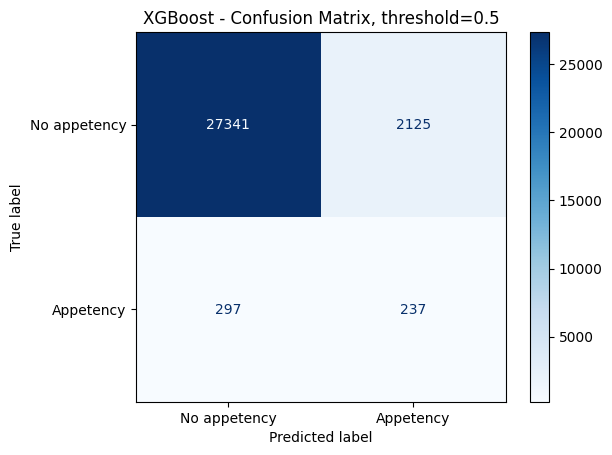

In [ ]:
xgb_cv_proba, xgb_cv_pred = evaluate_cv_classifier("XGBoost", final_xgb, X_train, y_train_arr, cv, threshold=0.5)

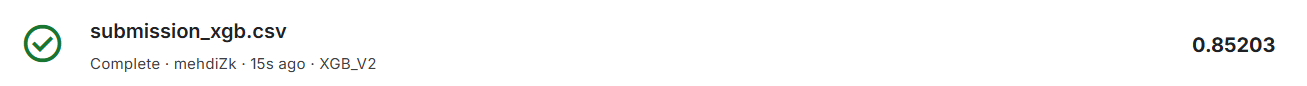

## F) LightGBM

In [13]:
# SECTION 5 — LIGHTGBM with early stopping

# LightGBM is faster than XGBoost on high-dimensional data
# due to histogram-based splits.
# is_unbalance=True is LightGBM's native imbalance handling —
# equivalent to scale_pos_weight but automatic.


lgb_params = {
    'learning_rate': [0.03, 0.05],
    'max_depth': [3, 5],
    'num_leaves': [15, 31], # tree complexity
    'subsample': [0.8],
    'colsample_bytree': [0.3, 0.5],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1],
}

best_lgb_auc    = 0
best_lgb_params = {}
best_lgb_model  = None

param_combinations_lgb = [
    dict(zip(lgb_params.keys(), v))
    for v in product(*lgb_params.values())
]

print(f"LightGBM: {len(param_combinations_lgb)} combinations 5 folds")

for params in param_combinations_lgb:
    fold_aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = lgb.LGBMClassifier(
            **params,
            n_estimators=2000,
            is_unbalance=True,
            random_state=123,
            n_jobs=-1,
            verbosity=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_lgb_auc:
        best_lgb_auc    = mean_auc
        best_lgb_params = params
        best_lgb_model  = model

LightGBM: 32 combinations 5 folds


In [14]:
print(f"Best AUC (CV): {best_lgb_auc:.4f}")
print(f"Best params: {best_lgb_params}")

Best AUC (CV): 0.7797
Best params: {'learning_rate': 0.03, 'max_depth': 3, 'num_leaves': 15, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_alpha': 0, 'reg_lambda': 1}


In [15]:
final_lgb = lgb.LGBMClassifier(
    **best_lgb_params,
    n_estimators=300,
    is_unbalance=True,
    random_state=123,
    n_jobs=-1,
    verbosity=-1
)
final_lgb.fit(X_train, y_train_arr)
lgb_pred = final_lgb.predict_proba(test)[:, 1]


LightGBM  Classification Report
              precision    recall  f1-score   support

           0     0.9918    0.8696    0.9267     29466
           1     0.0771    0.6011    0.1367       534

    accuracy                         0.8649     30000
   macro avg     0.5344    0.7354    0.5317     30000
weighted avg     0.9755    0.8649    0.9126     30000



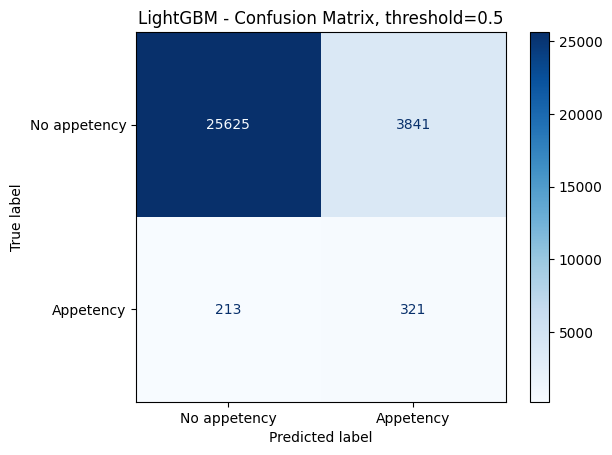

In [ ]:
lgb_cv_proba, lgb_cv_pred = evaluate_cv_classifier("LightGBM", final_lgb, X_train, y_train_arr, cv, threshold=0.5)

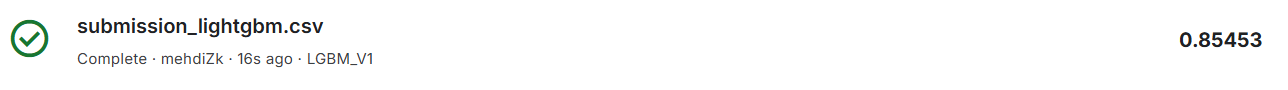

## G) Catboost

In [19]:
# CATBOOST with early stopping

# CatBoost handles class imbalance via auto_class_weights='Balanced'.
# It is also the slowest of the three GBM variants —
# the grid is kept lean deliberately.


cb_params = {
    'learning_rate': [0.05],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 5, 10],
}

best_cb_auc = 0
best_cb_params = {}

param_combinations_cb = [
    dict(zip(cb_params.keys(), v))
    for v in product(*cb_params.values())]

print(f"CatBoost: {len(param_combinations_cb)} combinations 5 folds")

for params in param_combinations_cb:
    fold_aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = CatBoostClassifier(
            **params,
            iterations=2000,
            auto_class_weights='Balanced',
            eval_metric='AUC',
            early_stopping_rounds=50,
            random_seed=123,
            verbose=0
        )
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            verbose=False
        )
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_cb_auc:
        best_cb_auc    = mean_auc
        best_cb_params = params

CatBoost: 9 combinations × 5 folds


In [20]:
print(f"Best AUC (CV): {best_cb_auc:.4f}")
print(f"Best params: {best_cb_params}")

Best AUC (CV): 0.8488
Best params: {'learning_rate': 0.05, 'depth': 4, 'l2_leaf_reg': 10}


In [21]:
final_cb = CatBoostClassifier(
    **best_cb_params,
    iterations=300,
    auto_class_weights='Balanced',
    random_seed=123,
    verbose=0)
    
final_cb.fit(X_train, y_train_arr)
cb_pred = final_cb.predict_proba(test)[:, 1]


CatBoost  Classification Report
              precision    recall  f1-score   support

           0     0.9922    0.8777    0.9314     29466
           1     0.0839    0.6180    0.1477       534

    accuracy                         0.8730     30000
   macro avg     0.5380    0.7478    0.5395     30000
weighted avg     0.9760    0.8730    0.9175     30000



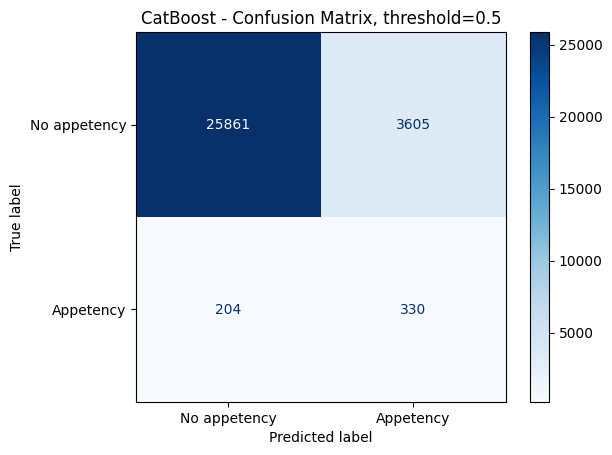

In [22]:
cb_cv_proba, cb_cv_pred = evaluate_cv_classifier("CatBoost", final_cb, X_train, y_train_arr, cv, threshold=0.5)

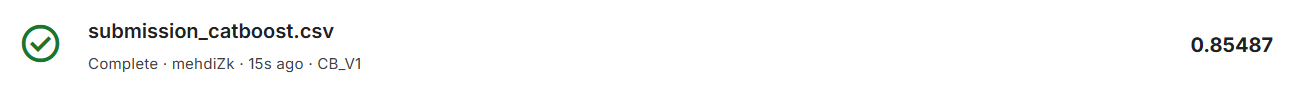

# IV - Model Comparison

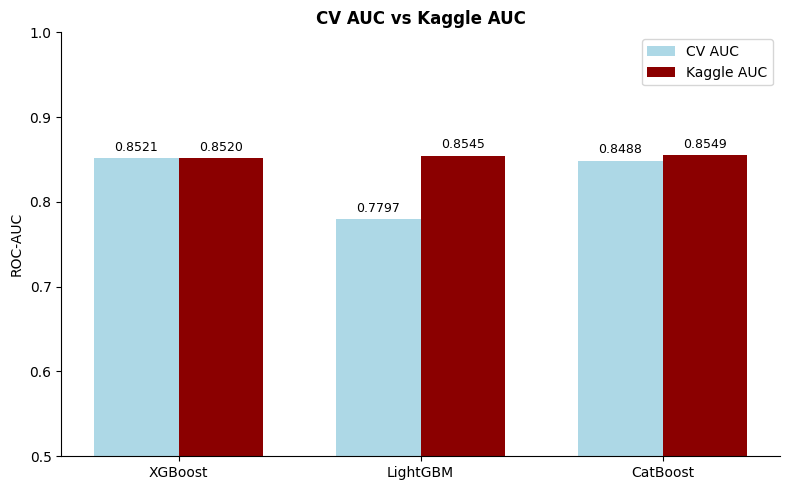

In [35]:
#  CV AUC vs Kaggle AUC

kaggle_scores = {
    "XGBoost":  0.85203,   
    "LightGBM": 0.85453,   
    "CatBoost": 0.85487,   
}

models = ["XGBoost", "LightGBM", "CatBoost"]
cv_aucs = [best_xgb_auc, best_lgb_auc, best_cb_auc]
kag_aucs = [kaggle_scores[m] if kaggle_scores[m] is not None else float("nan") for m in models]

x= np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_cv  = ax.bar(x - width / 2, cv_aucs,  width, label="CV AUC", color="lightblue")
bars_kag= ax.bar(x + width / 2, kag_aucs, width, label="Kaggle AUC", color="darkred")

ax.set_ylabel("ROC-AUC")
ax.set_title("CV AUC vs Kaggle AUC", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1)
ax.legend()

# adding the values on top of the bars
for bar in bars_cv:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars_kag:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

plt.show()

# V - Exporting

In [ ]:
# Export Kaggle submission files for XGBoost, LightGBM, and CatBoost

submission_xgb = pd.DataFrame({
    "ID": test.index,
    "Target_appetency": xgb_pred
})


submission_lgb = pd.DataFrame({
    "ID": test.index,
    "Target_appetency": lgb_pred
})

submission_cb = pd.DataFrame({
    "ID": test.index,
    "Target_appetency": cb_pred
})

submission_xgb.to_csv("output/submission_xgb.csv", index=False)
submission_lgb.to_csv("output/submission_lightgbm.csv", index=False)
submission_cb.to_csv("output/submission_catboost.csv", index=False)

display(submission_xgb.head())
display(submission_lgb.head())
display(submission_cb.head())

,ID,Target_appetency
0,877149,0.551101
1,109603,0.144513
2,560424,0.010390
3,386592,0.101109
4,857379,0.422011


,ID,Target_appetency
0,877149,0.612590
1,109603,0.103792
2,560424,0.017791
3,386592,0.291034
4,857379,0.539595


,ID,Target_appetency
0,877149,0.712475
1,109603,0.199156
2,560424,0.058269
3,386592,0.259014
4,857379,0.448368
